# COMP4318/5318 Assignment 2: Image Classification

#### Group number: 100
##### SID1: 530839244
##### SID2: 540958494
##### SID3: 550120560
##### SID4: 550053316

This template notebook includes code to load the  dataset and a skeleton for the main sections that should be included in the notebook. Please stick to this struture for your submitted notebook.

Please focus on making your code clear, with appropriate variable names and whitespace. Include comments and markdown text to aid the readability of your code where relevant. See the specification and marking criteria in the associated specification to guide you when completing your implementation.

## Setup and dependencies
Please use this section to list and set up all your required libraries/dependencies and your plotting environment. 

In [1]:
# --- Numerical / data handling ---------------------------------------------
import numpy as np
import pandas as pd

# --- Plotting ---------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", context="notebook")

# --- Classical ML -----------------------------------------------------------
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- Deep learning ----------------------------------------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers

# --- Utilities --------------------------------------------------------------
import time, os, json, itertools
from collections import Counter

# --- Reproducibility --------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# --- Hardware sanity check --------------------------------------------------
print("TensorFlow version :", tf.__version__)
print("Visible GPUs       :", tf.config.list_physical_devices("GPU"))


TensorFlow version : 2.16.2
Visible GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data loading, exploration, and preprocessing


Code to load the dataset is provided in the following cell. Please proceed with your data exploration and preprocessing in the remainder of this section.

### 1.1 Loading the dataset
We load the four NumPy arrays distributed on Canvas. The training and test splits are pre-defined; we will additionally carve a validation set out of the training split below for hyper-parameter selection.

In [2]:
# Load the dataset training and test sets as numpy arrays
X_train = np.load("Data/X_train.npy")
y_train = np.load("Data/y_train.npy")
X_test  = np.load("Data/X_test.npy")
y_test  = np.load("Data/y_test.npy")

print(f"X_train shape: {X_train.shape},  dtype: {X_train.dtype}")
print(f"y_train shape: {y_train.shape},  dtype: {y_train.dtype}")
print(f"X_test  shape: {X_test.shape},  dtype: {X_test.dtype}")
print(f"y_test  shape: {y_test.shape},  dtype: {y_test.dtype}")


X_train shape: (32000, 28, 28, 3),  dtype: uint8
y_train shape: (32000,),  dtype: uint8
X_test  shape: (8000, 28, 28, 3),  dtype: uint8
y_test  shape: (8000,),  dtype: uint8


### 1.2 Class definitions
PathMNIST is a 9-class colorectal histology dataset taken from the MedMNIST v2 benchmark. The class index → tissue type mapping below follows the official MedMNIST v2 release.

In [3]:
# PathMNIST class index -> tissue name (per MedMNIST v2)
class_names = {
    0: "Adipose",
    1: "Background",
    2: "Debris",
    3: "Lymphocytes",
    4: "Mucus",
    5: "Smooth Muscle",
    6: "Normal Colon Mucosa",
    7: "Cancer-associated Stroma",
    8: "Colorectal Adenocarcinoma Epithelium",
}
NUM_CLASSES = len(class_names)
print(f"Number of classes: {NUM_CLASSES}")
for k, v in class_names.items():
    print(f"  Class {k}: {v}")


Number of classes: 9
  Class 0: Adipose
  Class 1: Background
  Class 2: Debris
  Class 3: Lymphocytes
  Class 4: Mucus
  Class 5: Smooth Muscle
  Class 6: Normal Colon Mucosa
  Class 7: Cancer-associated Stroma
  Class 8: Colorectal Adenocarcinoma Epithelium


### 1.3 Sample sizes and class balance
We print the per-split sample counts using `len(...)` so the text never drifts out of sync with the actual arrays. PathMNIST is mildly imbalanced; the bar plot below confirms whether class re-weighting may be needed.

Training samples : 32,000
Test samples     : 8,000
Image dimensions : 28x28x3 (HxWxC)
Pixel dtype      : uint8 (range 0..255)


,class,count,proportion
0,Adipose,3490,10.91%
1,Background,3431,10.72%
2,Debris,3505,10.95%
3,Lymphocytes,3656,11.43%
4,Mucus,2950,9.22%
5,Smooth Muscle,4290,13.41%
6,Normal Colon Mucosa,2728,8.53%
7,Cancer-associated Stroma,3253,10.17%
8,Colorectal Adenocarcinoma Epithelium,4697,14.68%


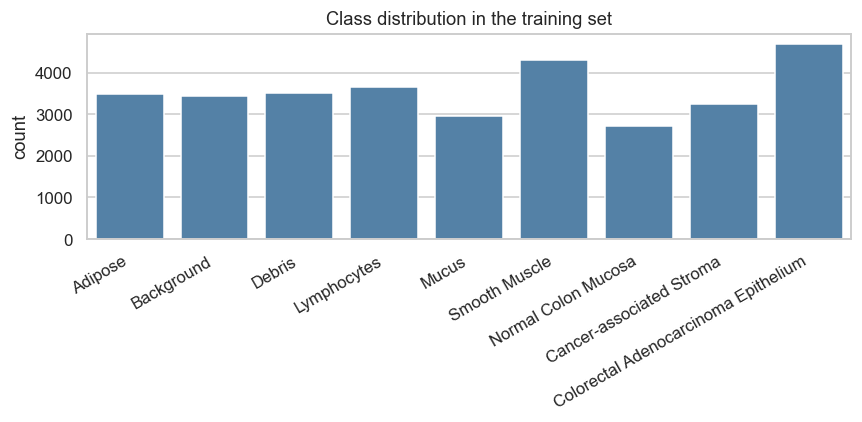

Imbalance ratio (max/min): 1.72


In [4]:
print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"Image dimensions : {X_train.shape[1]}x{X_train.shape[2]}x{X_train.shape[3]} (HxWxC)")
print(f"Pixel dtype      : {X_train.dtype} (range {X_train.min()}..{X_train.max()})")

unique, counts = np.unique(y_train, return_counts=True)
class_balance = pd.DataFrame({
    "class": [class_names[u] for u in unique],
    "count": counts,
    "proportion": counts / counts.sum(),
})
display(class_balance.style.format({"proportion": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=class_balance, x="class", y="count", ax=ax,
            color="steelblue")
ax.set_title("Class distribution in the training set")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")


### 1.4 Sample images per class
Three random images per class are shown to give an intuition for what the classifier has to discriminate. Many classes share a pinkish H&E stain colour and primarily differ by texture — a feature CNNs are particularly suited to capture.

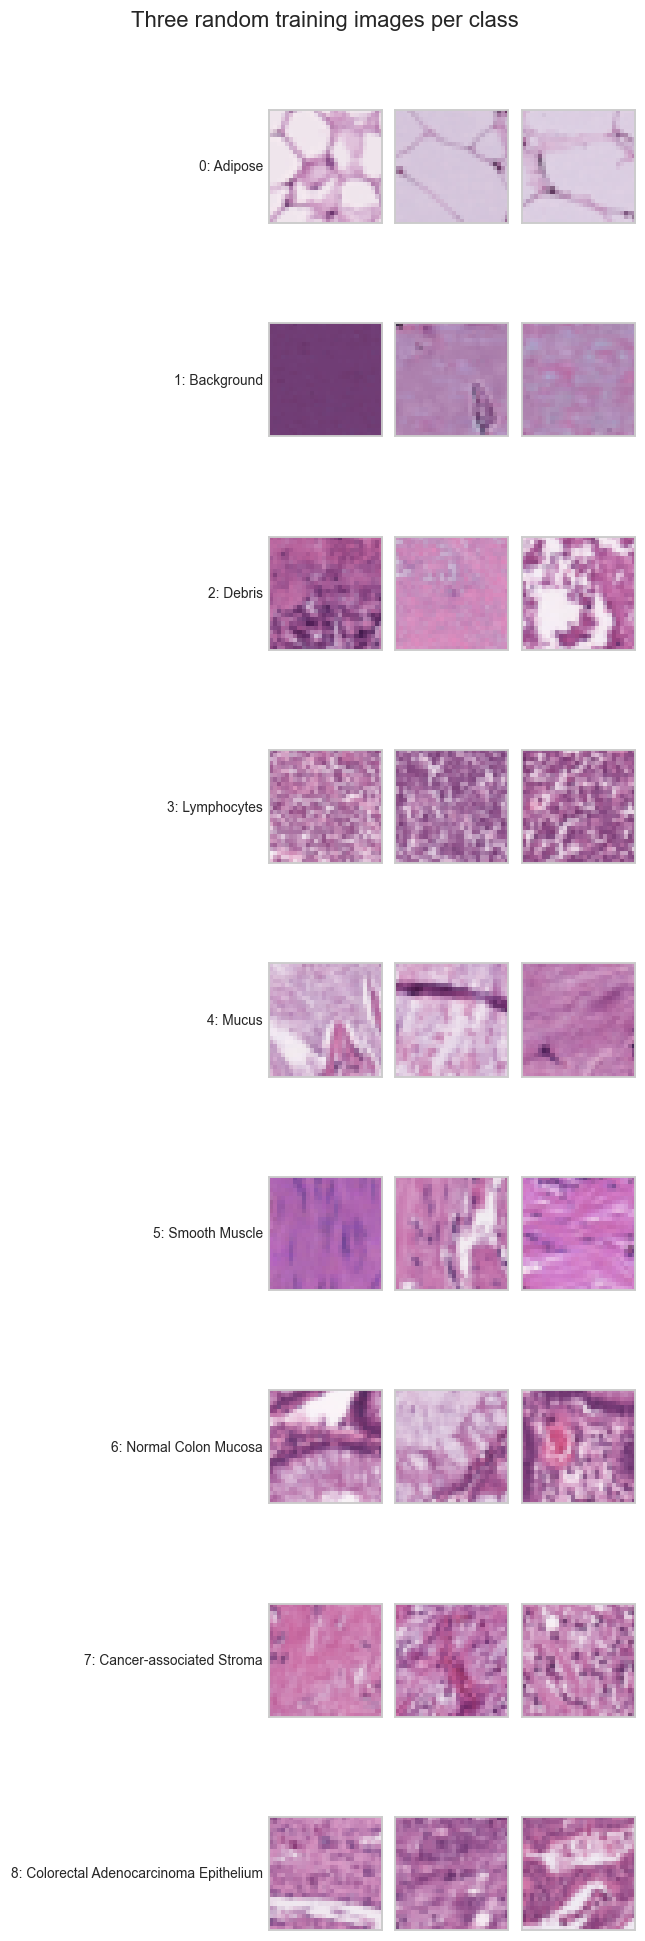

In [5]:
rng = np.random.default_rng(RANDOM_SEED)
classes = np.unique(y_train)
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(6, 2 * NUM_CLASSES))
for i, cls in enumerate(classes):
    idxs = np.where(y_train == cls)[0]
    selected = rng.choice(idxs, 3, replace=False)
    for j, k in enumerate(selected):
        ax = axes[i, j]
        ax.imshow(X_train[k])
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(f"{cls}: {class_names[cls]}", rotation=0,
                          ha="right", va="center", fontsize=9)
fig.suptitle("Three random training images per class", y=1.0)
plt.tight_layout()
plt.show()


### 1.5 Pixel intensity analysis
We inspect the per-channel pixel distribution to decide what kind of scaling is appropriate. The values lie in the standard 0–255 uint8 range, motivating a simple division by 255 to bring them into the [0, 1] range used by neural network optimisers.

Red    mean=188.65  std= 31.91
Green  mean=135.93  std= 45.60


Blue   mean=180.05  std= 32.18


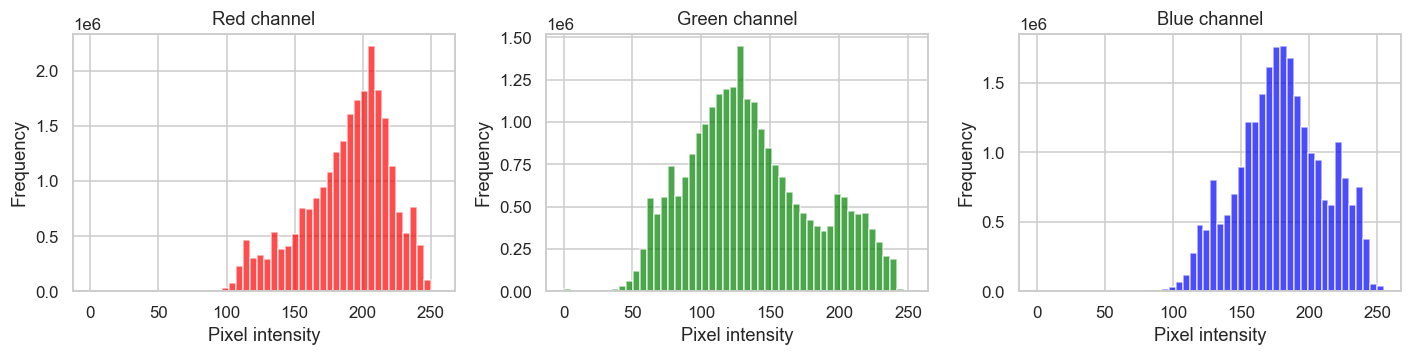

In [6]:
channel_names = ["Red", "Green", "Blue"]
colours = ["red", "green", "blue"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for c in range(3):
    data = X_train[..., c].ravel()
    axes[c].hist(data, bins=50, color=colours[c], alpha=0.7)
    axes[c].set_title(f"{channel_names[c]} channel")
    axes[c].set_xlabel("Pixel intensity")
    axes[c].set_ylabel("Frequency")
    print(f"{channel_names[c]:<5}  mean={data.mean():6.2f}  std={data.std():6.2f}")
plt.tight_layout()
plt.show()


### 1.6 Pre-processing
Two pre-processing pipelines are produced because the three classifiers consume data in different shapes:

* **Neural network branch (MLP / CNN)** — pixels are scaled to `[0, 1]` by dividing by 255. Keeping pixel intensities small and bounded improves gradient stability and avoids any single colour channel dominating because of its scale.
* **Classical-ML branch (SVM)** — each image is additionally flattened from `(28, 28, 3)` into a 2 352-dimensional feature vector, which is the input shape expected by `sklearn.svm.SVC`. We will further apply PCA inside the SVM pipeline (see §2) to keep the kernel evaluation tractable.

Standardisation (subtracting the per-feature mean and dividing by the standard deviation) was considered for the SVM branch and is applied as part of the final pipeline; we keep the un-standardised flattened tensors here so each model can scale them as required.

In [7]:
# Neural-network branch: scale pixels to [0, 1]
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm  = X_test.astype("float32")  / 255.0

# Classical-ML branch: flatten to (N, 2352)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat  = X_test_norm.reshape(X_test_norm.shape[0], -1)

print(f"Normalised pixel range : [{X_train_norm.min():.3f}, {X_train_norm.max():.3f}]")
print(f"NN-branch shape        : {X_train_norm.shape}")
print(f"Classical-branch shape : {X_train_flat.shape}")


Normalised pixel range : [0.000, 1.000]
NN-branch shape        : (32000, 28, 28, 3)
Classical-branch shape : (32000, 2352)


### 1.7 Train / validation split
The provided test set must only be used to evaluate the final selected models. For hyper-parameter tuning we therefore split the training set into a smaller training subset and a held-out validation subset. We use a stratified split so the class proportions are preserved on both sides.

In [8]:
VAL_FRACTION = 0.2

(X_tr_norm, X_val_norm,
 X_tr_flat, X_val_flat,
 y_tr,      y_val) = train_test_split(
    X_train_norm, X_train_flat, y_train,
    test_size=VAL_FRACTION,
    stratify=y_train,
    random_state=RANDOM_SEED,
)

print(f"Train subset (NN)        : {X_tr_norm.shape}")
print(f"Validation subset (NN)   : {X_val_norm.shape}")
print(f"Train subset (classical) : {X_tr_flat.shape}")
print(f"Validation (classical)   : {X_val_flat.shape}")

tr_props  = pd.Series(y_tr).value_counts(normalize=True).sort_index()
val_props = pd.Series(y_val).value_counts(normalize=True).sort_index()
props = pd.DataFrame({"train": tr_props, "val": val_props}).round(3)
props.index = props.index.map(class_names)
display(props)


Train subset (NN)        : (25600, 28, 28, 3)
Validation subset (NN)   : (6400, 28, 28, 3)
Train subset (classical) : (25600, 2352)
Validation (classical)   : (6400, 2352)


,train,val
Adipose,0.109,0.109
Background,0.107,0.107
Debris,0.110,0.110
Lymphocytes,0.114,0.114
Mucus,0.092,0.092
Smooth Muscle,0.134,0.134
Normal Colon Mucosa,0.085,0.085
Cancer-associated Stroma,0.102,0.102
Colorectal Adenocarcinoma Epithelium,0.147,0.147


### Examples of preprocessed data
Below we show the same training image after each of the two preprocessing pipelines. The neural-network input is a 3-channel 28×28 float tensor in `[0, 1]` and is visually identical to the original. The classical-ML input is the same tensor flattened to a 2 352-dimensional vector, visualised here as a stacked 1-D strip.

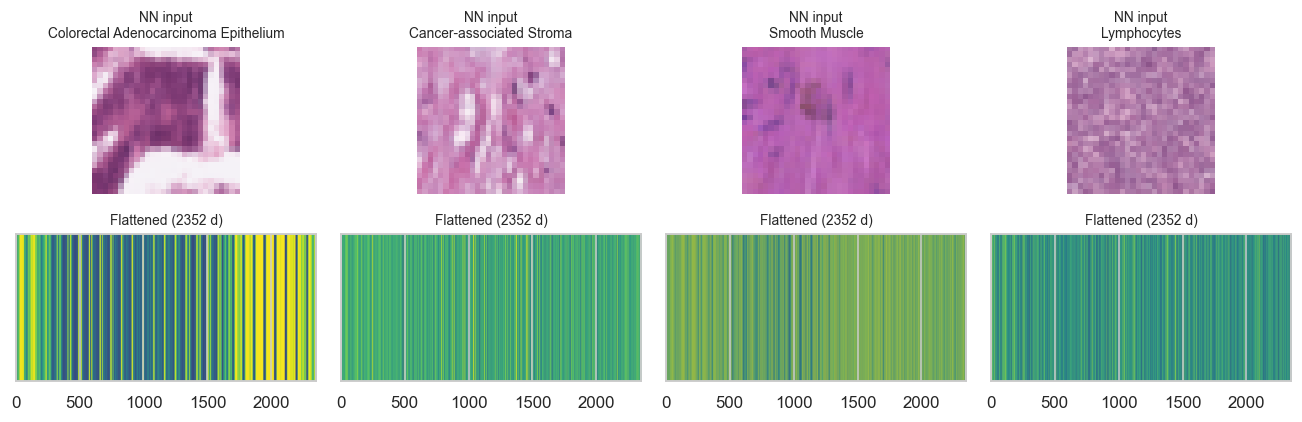

NN-input min/max : 0.000 / 1.000
Flat-input shape : (25600, 2352) (each row is one image)


In [9]:
sample_idx = rng.choice(len(X_tr_norm), 4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(12, 4))
for j, k in enumerate(sample_idx):
    axes[0, j].imshow(X_tr_norm[k])
    axes[0, j].set_title(f"NN input\n{class_names[int(y_tr[k])]}", fontsize=9)
    axes[0, j].axis("off")

    flat = X_tr_flat[k].reshape(1, -1)
    axes[1, j].imshow(flat, aspect="auto", cmap="viridis")
    axes[1, j].set_title("Flattened (2352 d)", fontsize=9)
    axes[1, j].set_yticks([])
plt.tight_layout()
plt.show()

print(f"NN-input min/max : {X_tr_norm.min():.3f} / {X_tr_norm.max():.3f}")
print(f"Flat-input shape : {X_tr_flat.shape} (each row is one image)")


## 2. Algorithm design and setup

### Algorithm of choice from first six weeks of course
We choose the **Support Vector Machine (SVM)** with an RBF kernel as our classical algorithm from the first six weeks of the course. SVMs perform well in high-dimensional feature spaces, are robust to over-fitting when the margin is properly regularised, and provide a non-linear decision boundary through the kernel trick — all desirable properties for raw flattened image features.

Because the flattened input has 2 352 dimensions and 32 000 samples, fitting an RBF SVM directly is computationally heavy. We therefore wrap the SVM in a pipeline that first **standardises** features and then projects them with **PCA** before the kernel evaluation. The PCA step controls runtime and reduces the impact of redundant pixel-level correlations.

### Fully connected neural network

### Convolutional neural network

## 3. Hyperparameter tuning

### Algorithm of choice from first six weeks of course

### Fully connected neural network

### Convolutional neural network

## 4. Final models
In this section, please ensure to include cells to train each model with its best hyperparmater combination independently of the hyperparameter tuning cells, i.e. don't rely on the hyperparameter tuning cells having been run.

### Algorithm of choice from first six weeks of course

### Fully connected neural network

### Convolutional neural network

## 5. AI Acknowledgement
Include acknowledgement of AI usage here. 
